## 2장 2강: 경사하강법, 옵티마이저 및 데이터 분할

머신러닝 데이터 가공과 시각화에 필요한 필수 도구들을 불러옵니다.

In [2]:
import pandas as pd

df = pd.read_csv('usa_housing.csv')
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


In [3]:
X = df[['SquareFeet', 'CrimeRate', 'SchoolRating']] # 특성(Feature), 독립변수
y = df['Price'] # 정답(Label), 종속변수

X.shape, y.shape


((300, 3), (300,))

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 17.64, 165.54,2753.89]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['SquareFeet','CrimeRate','SchoolRating']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.467e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [5]:
# 모델이 학습한 가중치와 절편
print(f'가중치 : {model.coef_}, 절편 : {model.intercept_}')
# 다항 회귀에서 수치가 커지면 더 큰 영향력이 있다.
# 면적, 범죄율, 학군 모두 집값에 주요한 요인이다.
# 정규화
# 기준을 통일함으로 비슷한 수준으로 영향력을 맞춘다.
#  최소값 - 최대값 ( Min Max Scaler ) : 0 ~ 1 사이로 압축
# X_{new} = X - 최소값 / 최대값 - 최소값 
# 표준 점수 ( Z - Score , StandardScaler) : 평균을 0으로 하고 표준편차를 1로 변환, 상대적 크기로 수치를 통일화
# X_{new}  = X - 평균 / 표준 편차 ㅇ

가중치 : [  17.64218384  165.54335017 2753.89459814], 절편 : 446703.79143559677


In [6]:
y_pred = model.predict(X)

y_pred[:10]

array([553677.4926239 , 504983.45760631, 512438.17995057, 507438.46740142,
       481041.34469987, 548602.92327148, 520154.49162671, 503931.32583249,
       521323.66394383, 535128.29765563])

In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X.values) # 준비 ( 기준 )

X_scaled1 = min_max_scaler.transform(X.values) # 변환 ( 0 ~ 1 )

X_scaled1[:10]

array([[0.95910512, 0.48643489, 0.5       ],
       [0.04690883, 0.92282958, 1.        ],
       [0.46403656, 0.52140273, 0.25      ],
       [0.44936252, 0.61756431, 0.        ],
       [0.08058696, 0.15544614, 0.375     ],
       [0.83954775, 0.04200161, 1.        ],
       [0.62424826, 0.10942524, 0.375     ],
       [0.36805389, 0.59947749, 0.125     ],
       [0.6062064 , 0.09354904, 0.5       ],
       [0.80611018, 0.37590434, 0.25      ]])

In [8]:
ss = StandardScaler()
ss.fit(X.values) 
X_scaled2 = ss.transform(X.values)
X_scaled2[:10]

array([[ 1.48724433, -0.02515304, -0.03620875],
       [-1.69135536,  1.48361236,  1.4620844 ],
       [-0.23785012,  0.09574274, -0.78535533],
       [-0.28898266,  0.42820612, -1.5345019 ],
       [-1.57400199, -1.16949409, -0.41078204],
       [ 1.07063989, -1.56171056,  1.4620844 ],
       [ 0.3204166 , -1.32860405, -0.41078204],
       [-0.57230721,  0.36567383, -1.15992862],
       [ 0.25754872, -1.38349351, -0.03620875],
       [ 0.95412476, -0.40729486, -0.78535533]])

In [9]:
model = LinearRegression()
model.fit(X_scaled2, y.values)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[21046.74, 4765.19, 7352.08]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.228e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[17.72,17.3 ,16.93]"


In [10]:
print(f'가중치 : {model.coef_}')
print(f'절편 : {model.intercept_}')

가중치 : [21046.73999149  4765.18597632  7352.0848553 ]
절편 : 522761.9166666667


데이터 스케일링 (숫자 압축하기)

데이터 쪼개기 (Train 60%, Valid 20%, Test 20%)

In [11]:
# 학습 데이터 (Train Set) : 모델이 학습 하는 데이터
# 검증 세트 ( Validetion Set) : 학습주기(Epoch, Batch)마다 모델을 평가하기 위한 데이터
# 테스트 세트 ( Test Set ) : 모델의 학습을 완료하고 모델의 성능을 평가 하기 위한 데이터

# => 학습 이후 테스트 셋은 예측 X
# -> 데이터를 비율에 맞게 섞어서 학습과 평가를 해야한다.

### 4. 데이터 분할 및 경사하강법 시각화
#### 4.1 오버슈팅 방지! 데이터 스케일링(Scaling)과 분할하기

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split # train set, validation set, test set 분리
import matplotlib.pyplot as plt


In [13]:
df = pd.read_csv('usa_housing.csv')
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


In [14]:
# 데이터 전처리 : 최근 데이터 + 범죄율이 낮은 데이터로 필터링

df = df[(df['YearBuilt'] > 2015 ) & (df['CrimeRate'] < 40)]
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
9,737147,3,2.6,4191,2017,0,1.65,66549,37.60,3
33,586232,4,1.3,3854,2021,2,1.39,30103,26.93,2
112,616588,2,1.2,3872,2016,0,0.17,61112,20.98,8
119,979858,5,3.8,4307,2020,0,0.38,41822,37.14,4
189,161087,5,2.4,964,2021,1,0.24,34022,12.80,3


In [15]:
X_sqft = df[['SquareFeet']].values
y_price = df['Price'].values

X_sqft.shape, y_price.shape

((10, 1), (10,))

- 정규화
- 표준 점수 (Z-Score, StandardScaler)

In [16]:
ss= StandardScaler()

# ss.fit(X_sqft)
# X_scaled = ss.transform(X_sqft)
# X_scaled = ss.fit_transform(X_sqft)
X_scaled = ss.fit_transform(X_sqft).flatten()
print(X_scaled)

[ 0.97965695  0.65953245  0.67663109  1.08984817 -2.08574882 -1.34575778
 -0.7644041   0.20261886  0.2824125   0.30521068]


In [17]:
# 데이터 쪼개기
# 1차 분할 - 테스트 세트 (20%)
X_train_tmp, X_test, y_train_tmp, y_test = train_test_split(
    X_scaled, y_price, test_size = 0.2, random_state=42
)

# 2차 분할 - 검증 세트 (20%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_tmp, y_train_tmp, test_size=0.2, random_state=42
)

print('전체 : ',X_scaled.shape)
print('훈련 세트 : ', X_train.shape)
print('검증 세트 : ', X_valid.shape)
print('테스트 세트 : ', X_test.shape)

전체 :  (10,)
훈련 세트 :  (6,)
검증 세트 :  (2,)
테스트 세트 :  (2,)


#### 4.2 AI 모델 최적화 학습 및 시각화

경사하강법을 위한 하이퍼파라미터 초기 세팅

In [25]:
import numpy as np

weight = 0.0          # 가중치(w): 집 크기에 따른 가격 영향력 (초기값 0)
bias = 0.0            # 편향(b): 기본적으로 깔고 가는 베이스 집값 (초기값 0)
learning_rate = 0.1   # 보폭(학습률): 스케일링을 했으므로 보폭을 조금 넓게 잡아도 안전합니다!
epochs = 300          # 훈련 횟수: 산을 내려가는 걸음을 총 200번 반복합니다.

# 훈련 과정에서 오차가 어떻게 줄어드는지 기록할 빈 리스트(수첩)를 만듭니다.
train_losses = []
valid_losses = []
history_w = []

N_train = len(X_train)
N_valid = len(X_valid)

 경사하강법 루프 시작 (200번 반복)

In [28]:
# 경사하강법 루프 시작 (200번 반복)
for epoch in range(epochs):
    # 훈련 세트: 현재 가중치로 집값을 예측해 봅니다 (y_pred = w * x + b)
    y_pred_train = weight * X_train + bias

    # 예측 집값과 실제 집값 차이의 제곱 평균(MSE Loss)을 구합니다.
    train_loss = np.mean((y_pred_train - y_train) ** 2)
    train_losses.append(train_loss)
    
    # 검증 세트: 모의고사 데이터를 넣어 현재 실력을 중간 점검합니다.
    y_pred_valid = weight * X_valid + bias
    valid_loss = np.mean((y_pred_valid - y_valid) ** 2)
    valid_losses.append(valid_loss)
    history_w.append(weight)
    
    # 기울기(Gradient) 구하기: 어느 방향으로 가야 오차가 줄어들지 미분 공식으로 찾습니다.
    dw = (2 / N_train) * np.sum((y_pred_train - y_train) * X_valid)
    db = (2 / N_train) * np.sum(y_pred_train - y_train)
    
    # 한 걸음 이동! (현재 위치 - 보폭 * 기울기)
    weight -= learning_rate * dw
    bias -= learning_rate * db

ValueError: operands could not be broadcast together with shapes (6,) (2,) 

인공지능이 길을 찾아간 과정을 그래프로 시각화하기

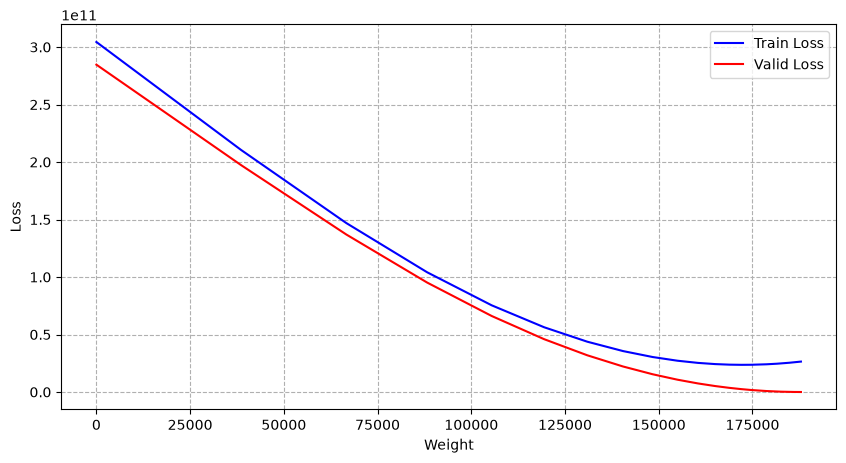

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(history_w, train_losses, color='blue', label='Train Loss')
plt.plot(history_w, valid_losses, color='red', label='Valid Loss')
plt.xlabel('Weight')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

In [ ]:
# 175000 시점 부터 과대적합 ( Over fitting )
# 더이상 학습을 해도 향상 되지 않고 loss가 더 커지는 상태

# 25000 시점 과소적합 ( Uncer Fitting )
# 학습이 덜 된 상태

# 학습을 적절한 횟수로 시켜야 좋다.
# -> 더이상 Loss가 떨어지지 않을 때 학습을 종료.
# -> Early Stopping 기법을 활용